In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [ ]:
df = pd.read_csv("npa_dataset.csv")
df.head()

,Loan_ID,Customer_ID,Loan_Amount,Loan_Type,Credit_Score,Repayment_History,Collateral_Value,Loan_Tenure,Default_Status
0,L00001,C00001,1742743,Personal,505,68.029548,481766,88,1
1,L00002,C00002,4354572,Business,654,66.635174,2912934,33,0
2,L00003,C00003,4976484,Vehicle,330,55.712543,1347431,217,1
3,L00004,C00004,2284489,Vehicle,543,70.504439,2808402,205,1
4,L00005,C00005,1620006,Business,788,80.254261,680588,73,0


# EDA

In [ ]:
df.shape

(300221, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300221 entries, 0 to 300220
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Loan_ID            300221 non-null  object 
 1   Customer_ID        300221 non-null  object 
 2   Loan_Amount        300221 non-null  int64  
 3   Loan_Type          300221 non-null  object 
 4   Credit_Score       300221 non-null  int64  
 5   Repayment_History  300221 non-null  float64
 6   Collateral_Value   300221 non-null  int64  
 7   Loan_Tenure        300221 non-null  int64  
 8   Default_Status     300221 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 20.6+ MB


In [ ]:
df.describe()

,Loan_Amount,Credit_Score,Repayment_History,Collateral_Value,Loan_Tenure,Default_Status
count,3.002210e+05,300221.000000,300221.000000,3.002210e+05,300221.000000,300221.000000
mean,2.530722e+06,575.282745,75.031481,1.992232e+06,185.535649,0.270927
std,1.427794e+06,159.167892,14.448399,1.153038e+06,100.431357,0.444439
min,5.000400e+04,300.000000,50.000042,1.800000e+01,12.000000,0.000000
25%,1.294031e+06,437.000000,62.489519,9.935240e+05,99.000000,0.000000
50%,2.535654e+06,575.000000,75.052078,1.988123e+06,185.000000,0.000000
75%,3.767650e+06,713.000000,87.555989,2.988275e+06,272.000000,1.000000
max,4.999999e+06,850.000000,99.999641,3.999995e+06,359.000000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Loan_Status"] = df["Default_Status"].map({
    0:"Performing",
    1:"Non-Performing"
})

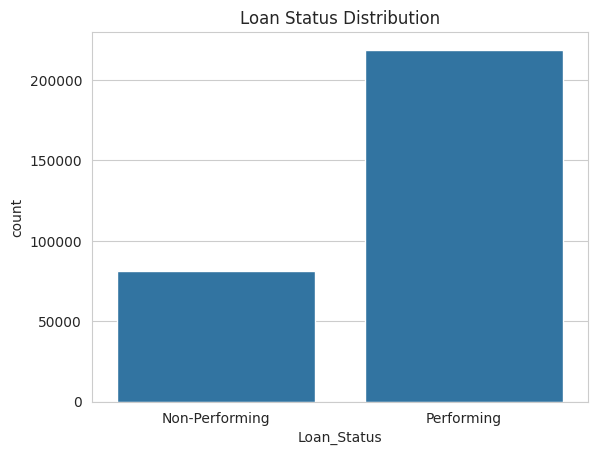

In [ ]:
sns.countplot(data=df, x="Loan_Status")
plt.title("Loan Status Distribution")
plt.show()

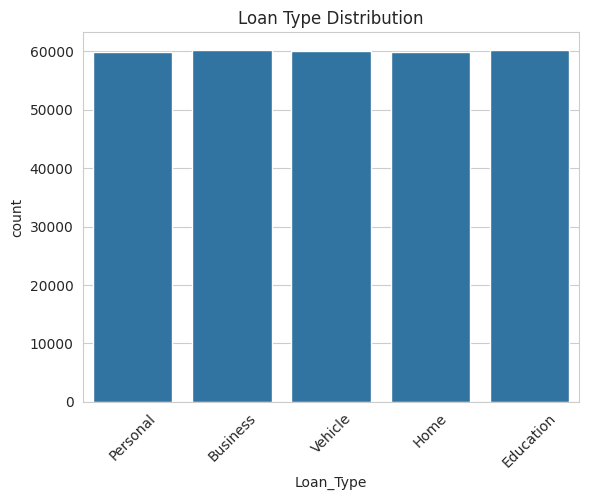

In [ ]:
sns.countplot(data=df, x="Loan_Type")
plt.title("Loan Type Distribution")
plt.xticks(rotation=45)
plt.show()

Collateral Ratio

In [ ]:
df["Collateral_Ratio"] = df["Collateral_Value"] / df["Loan_Amount"]

Credit Score Band

In [ ]:
df["Score_Band"] = pd.cut(
    df["Credit_Score"],
    bins=[0,500,650,750,900],
    labels=["Poor","Average","Good","Excellent"]
)

Repayment Behavior Bands

In [ ]:
df["Repayment_Band"] = pd.cut(
    df["Repayment_History"],
    bins=[0,60,75,90,100],
    labels=["Weak","Moderate","Good","Strong"]
)

Loan Size Segmentation

In [ ]:
df["Loan_Size"] = pd.qcut(
    df["Loan_Amount"],
    q=4,
    labels=["Small","Medium","Large","Very Large"]
)

Credit Score Band vs Default


*   Poor → high default
*   Excellent → low default



In [ ]:
pd.crosstab(df["Score_Band"], df["Loan_Status"], normalize="index") * 100

Loan_Status,Non-Performing,Performing
Score_Band,,
Poor,49.728266,50.271734
Average,33.034239,66.965761
Good,0.000000,100.000000
Excellent,0.000000,100.000000


Repayment Band vs Default

In [ ]:
pd.crosstab(df["Repayment_Band"], df["Loan_Status"], normalize="index") * 100

Loan_Status,Non-Performing,Performing
Repayment_Band,,
Weak,54.288764,45.711236
Moderate,54.308550,45.691450
Good,0.000000,100.000000
Strong,0.000000,100.000000


Loan Size vs Default

In [ ]:
pd.crosstab(df["Loan_Size"], df["Loan_Status"], normalize="index") * 100

Loan_Status,Non-Performing,Performing
Loan_Size,,
Small,26.919900,73.080100
Medium,27.180068,72.819932
Large,27.278662,72.721338
Very Large,26.992206,73.007794


Credit Score vs Loan Status

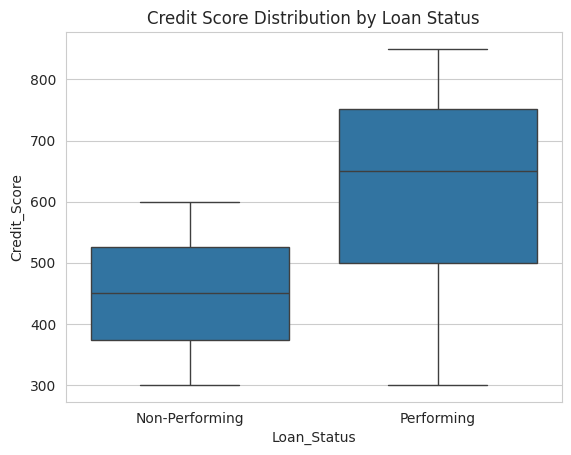

In [ ]:
sns.boxplot(data=df, x="Loan_Status", y="Credit_Score")
plt.title("Credit Score Distribution by Loan Status")
plt.show()

Repayment History vs Loan Status

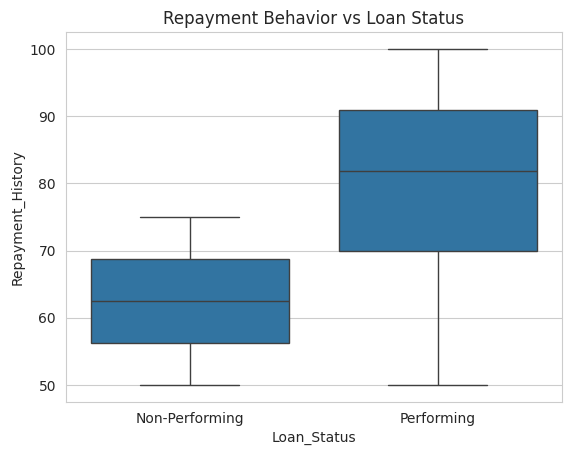

In [ ]:
sns.boxplot(data=df, x="Loan_Status", y="Repayment_History")
plt.title("Repayment Behavior vs Loan Status")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


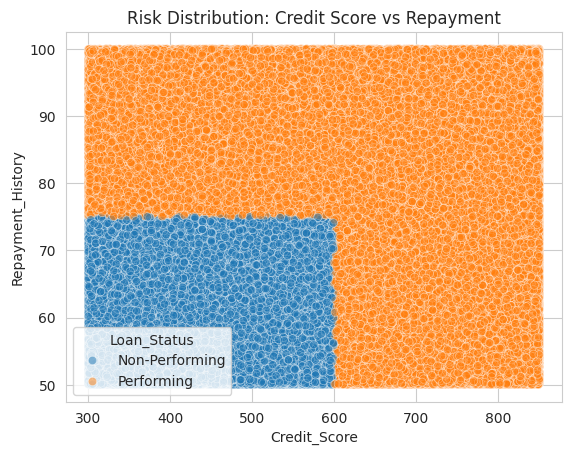

In [ ]:
sns.scatterplot(
    data=df,
    x="Credit_Score",
    y="Repayment_History",
    hue="Loan_Status",
    alpha=0.5
)
plt.title("Risk Distribution: Credit Score vs Repayment")
plt.show()

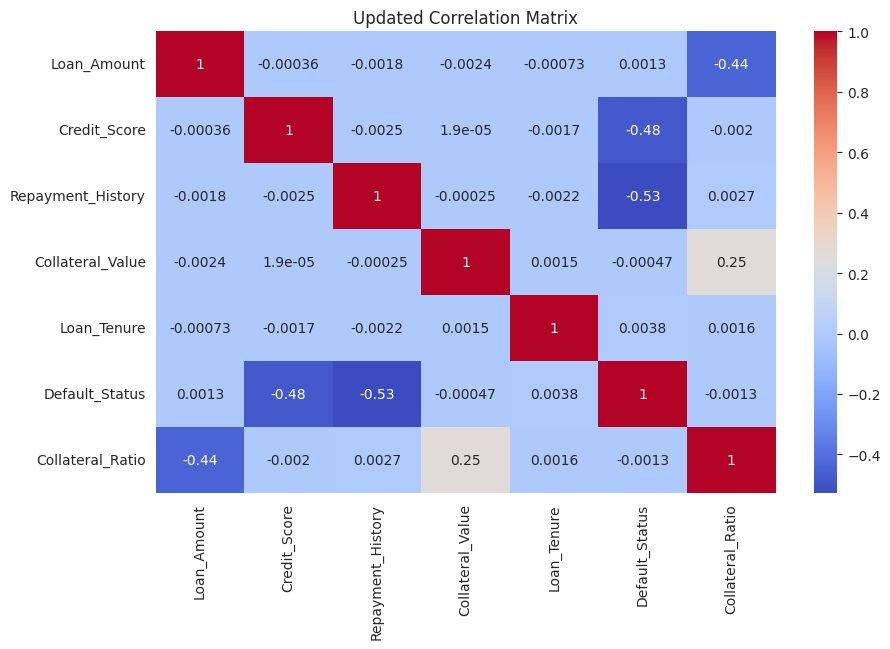

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Updated Correlation Matrix")
plt.show()

Identify High Risk Segment

In [ ]:
df["Risk_Score"] = (
    (700 - df["Credit_Score"]) * 0.4 +
    (100 - df["Repayment_History"]) * 0.4 +
    (1 - df["Collateral_Ratio"]) * 100 * 0.2
)

In [ ]:
df["Risk_Category"] = pd.qcut(
    df["Risk_Score"],
    q=3,
    labels=["Low Risk","Medium Risk","High Risk"]
)
pd.crosstab(df["Risk_Category"], df["Loan_Status"], normalize="index") * 100

Loan_Status,Non-Performing,Performing
Risk_Category,,
Low Risk,5.004297,94.995703
Medium Risk,23.330968,76.669032
High Risk,52.942822,47.057178


# Modeling

Select Features

In [ ]:
features = [
    "Credit_Score",
    "Repayment_History",
    "Loan_Amount",
    "Loan_Tenure",
    "Collateral_Ratio"
]
target = "Default_Status"

Create X and y

In [ ]:
X = df[features]
y = df[target]

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

Predictions

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

Evaluate Logistic Regression

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.9095673221046554
ROC-AUC: 0.9695324478974864
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     65727
           1       0.85      0.81      0.83     24340

    accuracy                           0.91     90067
   macro avg       0.89      0.88      0.88     90067
weighted avg       0.91      0.91      0.91     90067



ROC Curve

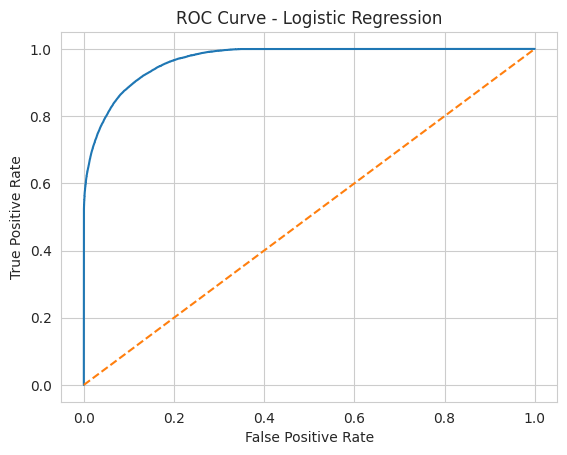

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_log)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

Feature Importance

Interpretation:
* Positive → increases default risk
* Negative → reduces risk

In [ ]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Importance": log_model.coef_[0]
}).sort_values(by="Importance", ascending=False)

coefficients

,Feature,Importance
3,Loan_Tenure,0.002976
2,Loan_Amount,-0.013681
4,Collateral_Ratio,-0.015953
0,Credit_Score,-3.285639
1,Repayment_History,-3.593847


Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Predictions

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

Evaluate Random Forest

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     65727
           1       1.00      1.00      1.00     24340

    accuracy                           1.00     90067
   macro avg       1.00      1.00      1.00     90067
weighted avg       1.00      1.00      1.00     90067



Feature Importance

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
1,Repayment_History,0.510536
0,Credit_Score,0.488939
4,Collateral_Ratio,0.000190
2,Loan_Amount,0.000189
3,Loan_Tenure,0.000146


In [ ]:
df["PD"] = log_model.predict_proba(scaler.transform(df[features]))[:,1]
df.sort_values(by="PD", ascending=False).head(10)

,Loan_ID,Customer_ID,Loan_Amount,Loan_Type,Credit_Score,Repayment_History,Collateral_Value,Loan_Tenure,Default_Status,Loan_Status,Collateral_Ratio,Score_Band,Repayment_Band,Loan_Size,Risk_Score,Risk_Category,PD
247937,L247938,C247938,2814754,Home,300,50.084046,2792794,307,1,Non-Performing,0.992198,Poor,Weak,Large,180.122417,High Risk,0.999808
208234,L208235,C208235,1165264,Personal,303,50.004931,1108770,313,1,Non-Performing,0.951518,Poor,Weak,Small,179.767662,High Risk,0.999803
106858,L106859,C106859,4697313,Business,300,50.122416,3170633,193,1,Non-Performing,0.674989,Poor,Weak,Very Large,186.451260,High Risk,0.999802
8606,L08607,C08607,2507856,Vehicle,302,50.022220,1796263,19,1,Non-Performing,0.716254,Poor,Weak,Medium,184.866023,High Risk,0.999802
259439,L259440,C259440,2671364,Vehicle,302,50.057426,2055076,52,1,Non-Performing,0.769298,Poor,Weak,Large,183.791062,High Risk,0.999800
262755,L262756,C262756,4365170,Business,301,50.107116,371720,200,1,Non-Performing,0.085156,Poor,Weak,Very Large,197.854035,High Risk,0.999800
6605,L06606,C06606,1297486,Education,303,50.018551,2307480,52,1,Non-Performing,1.778424,Poor,Weak,Medium,163.224103,High Risk,0.999800
91778,L91779,C91779,157776,Vehicle,301,50.291225,438,241,1,Non-Performing,0.002776,Poor,Weak,Small,199.427988,High Risk,0.999799
181328,L181329,C181329,2298212,Personal,300,50.272525,3852383,228,1,Non-Performing,1.676252,Poor,Weak,Medium,166.365945,High Risk,0.999799
20673,L20674,C20674,848086,Vehicle,302,50.155299,2655856,313,1,Non-Performing,3.131588,Poor,Weak,Small,136.506119,High Risk,0.999799


In [ ]:
df["PD_Risk_Category"] = pd.cut(
    df["PD"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)
pd.crosstab(df["PD_Risk_Category"], df["Loan_Status"], normalize="index")*100

Loan_Status,Non-Performing,Performing
PD_Risk_Category,,
Low Risk,4.494704,95.505296
Medium Risk,40.730337,59.269663
High Risk,88.380675,11.619325


What You Just Built

* Predictive model
* Probability of default
* Risk segmentation
* Feature importance
* Model comparison

How to Explain in Viva

Logistic Regression was used as a baseline interpretable model, while Random Forest improved predictive performance. Probability of Default (PD) was derived to support risk-based decision making.

What to Screenshot

* ROC Curve
* Classification report
* Feature importance table
* Top high-risk borrowers
* PD distribution

In [ ]:
final_dataset = df[[
    "Loan_ID",
    "Customer_ID",
    "Loan_Type",
    "Loan_Amount",
    "Loan_Tenure",
    "Credit_Score",
    "Score_Band",
    "Repayment_History",
    "Repayment_Band",
    "Collateral_Value",
    "Collateral_Ratio",
    "Default_Status",
    "Loan_Status",
    "PD",
    "PD_Risk_Category"
]]

In [ ]:
final_dataset.head()

,Loan_ID,Customer_ID,Loan_Type,Loan_Amount,Loan_Tenure,Credit_Score,Score_Band,Repayment_History,Repayment_Band,Collateral_Value,Collateral_Ratio,Default_Status,Loan_Status,PD,PD_Risk_Category
0,L00001,C00001,Personal,1742743,88,505,Average,68.029548,Moderate,481766,0.276441,1,Non-Performing,0.466764,Medium Risk
1,L00002,C00002,Business,4354572,33,654,Good,66.635174,Moderate,2912934,0.668937,0,Performing,0.052640,Low Risk
2,L00003,C00003,Vehicle,4976484,217,330,Poor,55.712543,Weak,1347431,0.270760,1,Non-Performing,0.998525,High Risk
3,L00004,C00004,Vehicle,2284489,205,543,Average,70.504439,Moderate,2808402,1.229335,1,Non-Performing,0.176718,Low Risk
4,L00005,C00005,Business,1620006,73,788,Excellent,80.254261,Good,680588,0.420114,0,Performing,0.000121,Low Risk


In [ ]:
final_dataset.to_csv("final_dataset.csv", index=False)

In [ ]:
sample_df = final_dataset.sample(5000, random_state=42)
sample_df.to_csv("sample_dataset.txt", index=False)

In [ ]:
sample_df.head(100)

,Loan_ID,Customer_ID,Loan_Type,Loan_Amount,Loan_Tenure,Credit_Score,Score_Band,Repayment_History,Repayment_Band,Collateral_Value,Collateral_Ratio,Default_Status,Loan_Status,PD,PD_Risk_Category
149096,L149097,C149097,Education,4137059,175,542,Average,81.315726,Good,965343,0.233340,0,Performing,0.014438,Low Risk
163015,L163016,C163016,Home,4115400,359,343,Poor,64.820131,Moderate,1812577,0.440438,1,Non-Performing,0.981916,High Risk
93816,L93817,C93817,Personal,2535498,22,842,Excellent,90.830746,Strong,2608169,1.028661,0,Performing,0.000003,Low Risk
280294,L280295,C280295,Education,2250024,48,433,Poor,94.562828,Strong,3720679,1.653617,0,Performing,0.005165,Low Risk
150633,L150634,C150634,Business,2471451,252,511,Average,88.736287,Good,2113795,0.855285,0,Performing,0.004434,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238236,L238237,C238237,Home,1295826,169,308,Poor,61.870584,Moderate,2333372,1.800683,1,Non-Performing,0.995795,High Risk
48768,L48769,C48769,Education,4397813,58,820,Excellent,60.341994,Moderate,482094,0.109621,0,Performing,0.008589,Low Risk
112614,L112615,C112615,Personal,3725691,268,827,Excellent,75.017167,Good,3698826,0.992789,0,Performing,0.000196,Low Risk
20166,L20167,C20167,Vehicle,766748,180,496,Poor,66.881677,Moderate,2515873,3.281225,1,Non-Performing,0.583987,Medium Risk
